In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

df = pd.DataFrame(X, columns=['Annual_Income', 'Spending_Score'])

In [4]:
df

,Annual_Income,Spending_Score
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542
...,...,...
295,1.973698,1.579798
296,2.518342,1.391766
297,0.438990,4.535929
298,0.369479,7.791105


In [5]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(df)

centroids = kmeans.cluster_centers_

In [6]:
df.head()

,Annual_Income,Spending_Score,Cluster
0,0.836857,2.136359,1
1,-1.413658,7.409623,2
2,1.155213,5.099619,0
3,-1.018616,7.814915,2
4,1.271351,1.892542,1


<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

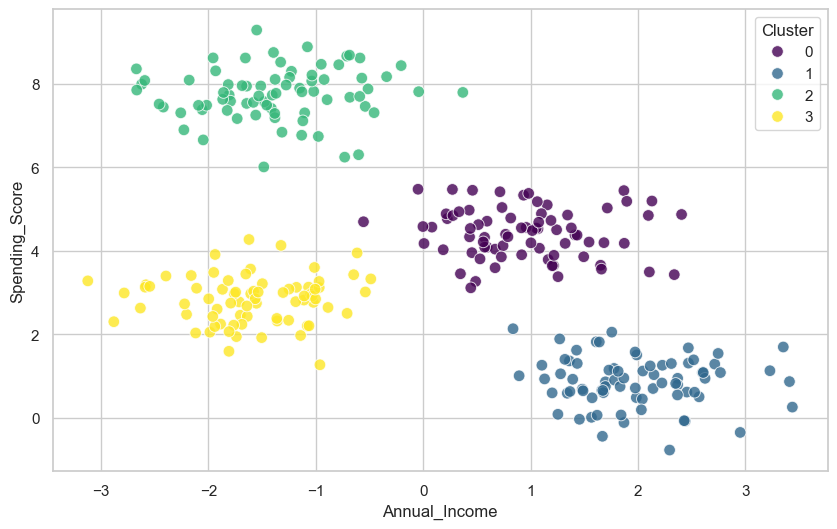

In [7]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='Cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)

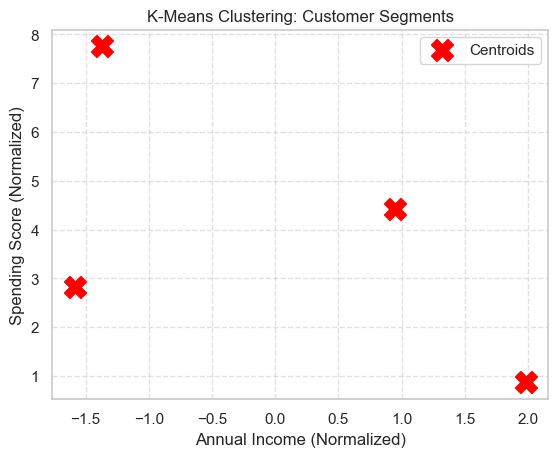

In [8]:
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=250, 
    c='red', 
    marker='X', 
    label='Centroids'
)

plt.title('K-Means Clustering: Customer Segments')
plt.xlabel('Annual Income (Normalized)')
plt.ylabel('Spending Score (Normalized)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()